# DDI-Aware LEADER: Medication Recommender
## Phase 1: Data Preparation + Phase 2-6: Training & Evaluation

**How to use this notebook:**
1. Upload your project folder to Google Drive
2. Run cells in order
3. GPU required for Phase 2+ (training)

## Cell 0: Mount Google Drive & Setup Project

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/Luan-van-thac-sy/DDI-Drug-Recommender.git

Cloning into 'DDI-Drug-Recommender'...
remote: Enumerating objects: 266, done.
remote: Counting objects: 100% (266/266), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 266 (delta 129), reused 243 (delta 106), pack-reused 0 (from 0)
Receiving objects: 100% (266/266), 166.15 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [3]:
%cd DDI-Drug-Recommender/

/content/DDI-Drug-Recommender


In [4]:
!rm -rf data

In [ ]:
!mkdir -p model


In [ ]:
# Keep working directory at the repo root (do not `cd model/`).
import os
print("Working dir:", os.getcwd())


/content/model


In [5]:
!pip install -r requirements_fi.txt


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 31.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 15.4 MB/s eta 0:00:00
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.2/244.2 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 161.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 25.1 MB/s eta 0:00:00


In [6]:
!pip install -q transformers==4.36.2


In [7]:
import os

# === EDIT THIS PATH to match where you uploaded the project in Google Drive ===
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Thesis/MyModel"

# imporπt os
# # Copy project to local storage (faster I/O than Drive)
# !cp -r "{DRIVE_PROJECT_PATH}" /content/project
# %cd /content/project
DRIVE_INPUT_PATH = os.path.join(DRIVE_PROJECT_PATH, "input")
LOCAL_INPUT_PATH = "input"
# Ensure the parent directory exists
os.makedirs("input", exist_ok=True)
# Remove the local folder so we can replace it with a link to Drive
if os.path.exists(LOCAL_INPUT_PATH):
    !rm -rf "{LOCAL_INPUT_PATH}"
# Create the symbolic link
!ln -s "{DRIVE_INPUT_PATH}" "{LOCAL_INPUT_PATH}"




In [8]:
DRIVE_INPUT_PATH = os.path.join(DRIVE_PROJECT_PATH, "output")
LOCAL_INPUT_PATH = "output"
# Ensure the parent directory exists
os.makedirs("output", exist_ok=True)
# Remove the local folder so we can replace it with a link to Drive
if os.path.exists(LOCAL_INPUT_PATH):
    !rm -rf "{LOCAL_INPUT_PATH}"
# Create the symbolic link
!ln -s "{DRIVE_INPUT_PATH}" "{LOCAL_INPUT_PATH}"



In [18]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Thesis/Leader/Leader-origin"
DRIVE_INPUT_PATH = os.path.join(DRIVE_PROJECT_PATH, "resources")
LOCAL_INPUT_PATH = "resources"
# Ensure the parent directory exists
os.makedirs("resources", exist_ok=True)
# Remove the local folder so we can replace it with a link to Drive
if os.path.exists(LOCAL_INPUT_PATH):
    !rm -rf "{LOCAL_INPUT_PATH}"
# Create the symbolic link
!ln -s "{DRIVE_INPUT_PATH}" "{LOCAL_INPUT_PATH}"


In [ ]:

# === EDIT THIS PATH to match where you uploaded the project in Google Drive ===
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Thesis/MyModel/data_train_leader"

# imporπt os
# # Copy project to local storage (faster I/O than Drive)
# !cp -r "{DRIVE_PROJECT_PATH}" /content/project
# %cd /content/project
DRIVE_INPUT_PATH = os.path.join(DRIVE_PROJECT_PATH, "data")
LOCAL_INPUT_PATH = "data"
# Ensure the parent directory exists
os.makedirs("data", exist_ok=True)
# Remove the local folder so we can replace it with a link to Drive
if os.path.exists(LOCAL_INPUT_PATH):
    !rm -rf "{LOCAL_INPUT_PATH}"
# Create the symbolic link
!ln -s "{DRIVE_INPUT_PATH}" "{LOCAL_INPUT_PATH}"




In [ ]:

# === EDIT THIS PATH to match where you uploaded the project in Google Drive ===
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Thesis/MyModel/model_train_leader/model"

# imporπt os
# # Copy project to local storage (faster I/O than Drive)
# !cp -r "{DRIVE_PROJECT_PATH}" /content/project
# %cd /content/project
DRIVE_INPUT_PATH = os.path.join(DRIVE_PROJECT_PATH, "saved")
LOCAL_INPUT_PATH = "saved"
# Ensure the parent directory exists
os.makedirs("saved", exist_ok=True)
# Remove the local folder so we can replace it with a link to Drive
if os.path.exists(LOCAL_INPUT_PATH):
    !rm -rf "{LOCAL_INPUT_PATH}"
# Create the symbolic link
!ln -s "{DRIVE_INPUT_PATH}" "{LOCAL_INPUT_PATH}"




## Cell 1: Install Dependencies

## Phase 1: Data Preparation
Run `prepare_data.py` to convert CSV → LEADER JSONL format and copy artifacts.

In [9]:
# Run Phase 1: Data Preparation
# Run Phase 1: Data Preparation
!mv improve/prepare_data.py .
!python ./prepare_data.py


Phase 1: Data Preparation for DDI-Aware LEADER

[1] Loading vocabulary from /content/DDI-Drug-Recommender/output/mimic-iii/voc_final.pkl
    diag_voc: 2025 codes
    med_voc:  151 codes
    pro_voc:  630 codes

[1b] Loading DDI adjacency from /content/DDI-Drug-Recommender/output/mimic-iii/ddi_A_final.pkl
    ddi_adj shape: (151, 151)

[1c] Building MDC matrix...
    MDC matrix shape: (2025, 151), rules matched: 29, pairs: 228

[2] Loading CSV from /content/DDI-Drug-Recommender/input/data4LLM_with_note.csv
    Rows: 14614
    Unique patients: 6317

[3] Building LEADER-format records...
    Records built: 6317

[4] Splitting data (0.8/0.1/0.09999999999999995)...
    Train: 5053, Val: 631, Test: 633

[5] Saving JSONL files to /content/data/mimic3/handled

[6] Building profile_dict.json...
    GENDER values: ['female', 'male']
    AGE values: 76 unique ages

[7] Copying artifacts to /content/data/mimic3/handled
    Copied voc_final.pkl → /content/data/mimic3/handled
    Copied ddi_A_final.

In [11]:
!ls

baseline     improve_plan.md  models		   test_ddi_fixes.py
CLAUDE.md    input	      output		   test_single_input.py
docs	     LICENSE	      prepare_data.py	   trainers
evaluate.py  llm	      README.md		   utils
experiment   main_distill.py  requirements_fi.txt
generators   main_llm_cls.py  requirements.txt
improve      main_medrec.py   run_quick_test.sh


In [12]:
!ls -s "/content/drive/MyDrive/Thesis/MyModel/data_train_leader/data" .

.:
total 164
 4 baseline	     4 LICENSE		 4 requirements_fi.txt
 4 CLAUDE.md	     4 llm		 4 requirements.txt
 4 docs		    12 main_distill.py	 4 run_quick_test.sh
16 evaluate.py	    12 main_llm_cls.py	 8 test_ddi_fixes.py
 4 experiment	    12 main_medrec.py	12 test_single_input.py
 4 generators	     4 models		 4 trainers
 4 improve	     0 output		 4 utils
16 improve_plan.md  16 prepare_data.py
 0 input	     4 README.md

/content/drive/MyDrive/Thesis/MyModel/data_train_leader/data:
total 0


In [16]:
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Thesis/MyModel/data_train_leader'
DRIVE_INPUT_PATH = os.path.join(DRIVE_PROJECT_PATH, "data")
LOCAL_INPUT_PATH = "data"
# Ensure the parent directory exists
os.makedirs("data", exist_ok=True)
# Remove the local folder so we can replace it with a link to Drive
if os.path.exists(LOCAL_INPUT_PATH):
    !rm -rf "{LOCAL_INPUT_PATH}"
# Create the symbolic link
!ln -s "{DRIVE_INPUT_PATH}" "{LOCAL_INPUT_PATH}"

## Phase 1: Verify Data
Check all files created correctly and inspect sample records.

In [14]:
import json, dill, numpy as np, os

data_dir = "data/mimic3/handled/"

# Check all files exist
files = ['voc_final.pkl', 'profile_dict.json', 'train_leader.json',
         'val_leader.json', 'test_leader.json',
         'full/ddi_A_final.pkl', 'full/ehr_adj_final.pkl']

print("=== File Check ===")
for f in files:
    path = os.path.join(data_dir, f)
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {f} ({size:,} bytes)")

# Load and inspect
voc = dill.load(open(data_dir + "voc_final.pkl", "rb"))
ddi = dill.load(open(data_dir + "full/ddi_A_final.pkl", "rb"))
print(f"\nVocab: diag={len(voc['diag_voc'].word2idx)}, med={len(voc['med_voc'].word2idx)}, proc={len(voc['pro_voc'].word2idx)}")
print(f"DDI matrix: {ddi.shape}, pairs: {np.count_nonzero(ddi)//2}")

# Load train data
train = [json.loads(l) for l in open(data_dir + "train_leader.json")]
val = [json.loads(l) for l in open(data_dir + "val_leader.json")]
test = [json.loads(l) for l in open(data_dir + "test_leader.json")]
print(f"\nTrain: {len(train)}, Val: {len(val)}, Test: {len(test)}")

# Show sample record
rec = train[0]
print(f"\n=== Sample Record ===")
print(f"Patient: {rec['subject_id']}")
print(f"Visits: {len(rec['records']['diagnosis'])}")
print(f"Target drugs: {len(rec['drug_code'])} medications")
print(f"Drug codes: {rec['drug_code'][:5]}...")
print(f"Profile: {rec['profile']}")
print(f"\nPrompt (first 300 chars):\n{rec['input'][:300]}...")
print(f"\nHas clinical notes: {'Clinical Notes:' in rec['input']}")

=== File Check ===
  [OK] voc_final.pkl (51,184 bytes)
  [OK] profile_dict.json (2,760 bytes)
  [OK] train_leader.json (24,033,296 bytes)
  [OK] val_leader.json (3,028,128 bytes)
  [OK] test_leader.json (2,959,519 bytes)
  [OK] full/ddi_A_final.pkl (182,604 bytes)
  [OK] full/ehr_adj_final.pkl (182,604 bytes)

Vocab: diag=2025, med=151, proc=630
DDI matrix: (151, 151), pairs: 1425

Train: 5053, Val: 631, Test: 633

=== Sample Record ===
Patient: 23365
Visits: 2
Target drugs: 30 medications
Drug codes: ['DB00184', 'DB00512', 'DB00421', 'DB00695', 'DB00813']...
Profile: {'GENDER': 'male', 'AGE': '51'}

Prompt (first 300 chars):
The patient has 1 times ICU visits. 
 In 1 visit, the patient had diagnosis: Cirrhosis of Liver due to Alcohol, Heart Failure; procedures: Liver Transplant, Cadaveric Transplant. The patient was prescribed drugs: Methylprednisolone hemisuccinate, Tacrolimus, Tazobactam, Vancomycin, Trimethoprim, Sul...

Has clinical notes: True


## Phase 1: DDI Matrix Visualization
Quick look at the DDI interaction patterns in our dataset.

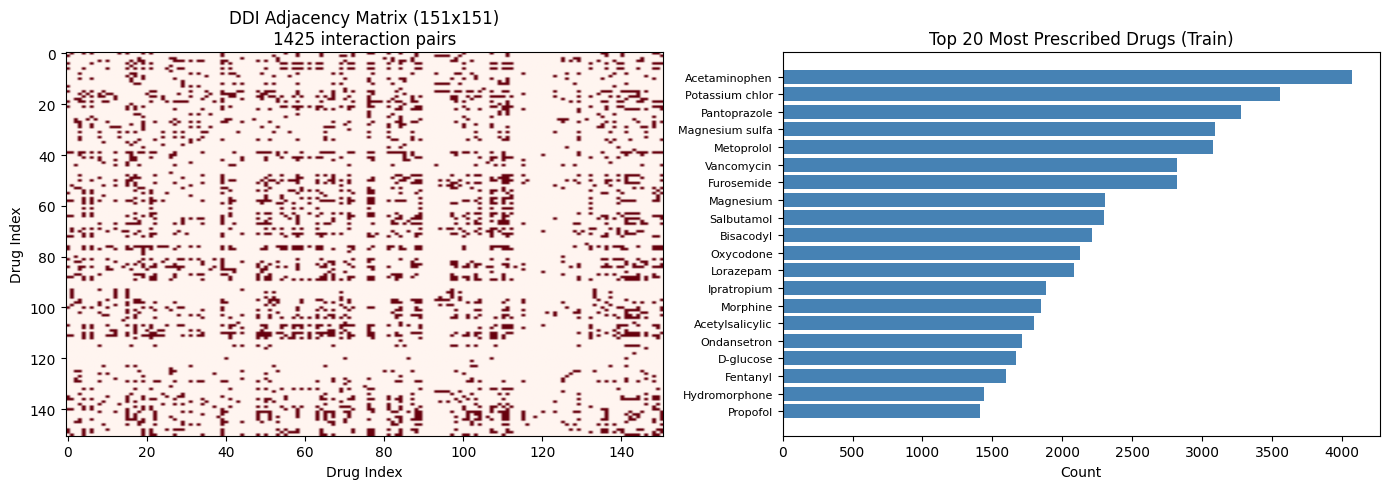

Saved to improve/phase1_data_overview.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DDI adjacency matrix heatmap
axes[0].imshow(ddi, cmap='Reds', aspect='auto')
axes[0].set_title(f"DDI Adjacency Matrix ({ddi.shape[0]}x{ddi.shape[1]})\n{np.count_nonzero(ddi)//2} interaction pairs")
axes[0].set_xlabel("Drug Index")
axes[0].set_ylabel("Drug Index")

# Drug count distribution in training data
from collections import Counter
drug_counts = Counter()
for rec in train:
    drug_counts.update(rec['drug_code'])
top20 = drug_counts.most_common(20)
db2name = json.load(open("output/mimic-iii/med_db2name.json"))
names = [db2name.get(d, d)[:15] for d, _ in top20]
counts = [c for _, c in top20]
axes[1].barh(range(len(names)), counts, color='steelblue')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_title("Top 20 Most Prescribed Drugs (Train)")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("improve/phase1_data_overview.png", dpi=150)
plt.show()
print("Saved to improve/phase1_data_overview.png")

---
## Phase 2+: Training (GPU Required)
The cells below require GPU. Make sure Runtime > Change runtime type > GPU is selected.

**Note:** Phases 2-6 require the LEADER model code changes (DDI loss, adaptive beta).
These changes should be made locally before uploading to Drive. See `improve_plan.md` for details.

In [ ]:
# Check GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Training will be very slow.")
    print("Go to Runtime > Change runtime type > GPU")

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

In [ ]:
# Download BioMistral-7B model
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="BioMistral/BioMistral-7B",
    local_dir="resources/biomistral-7b",
    local_dir_use_symlinks=False                        # store real files
)


### Stage 1: Train LLM Teacher (skip if using offline/pre-cached mode)

In [ ]:

# !deepspeed --num_gpus=1 main_llm_cls.py \
#     --deepspeed llm/ds.config \
#     --do_train \
#     --train_file data/mimic3/handled/train_leader.json \
#     --cache_dir data/mimic3/handled/ \
#     --prompt_column input \
#     --response_column drug_code \
#     --overwrite_cache \
#     --model_name_or_path resources/biomistral-7b \
#     --output_dir saved/lora-ddi \
#     --overwrite_output_dir \
#     --max_source_length 1024 \
#     --max_target_length 256 \
#     --per_device_train_batch_size 4 \
#     --gradient_accumulation_steps 2 \
#     --max_steps 10 \
#     --logging_steps 100 \
#     --save_steps 10 \
#     --learning_rate 2e-4 \
#     --lora_rank 8 \
#     --trainable q_proj,k_proj,v_proj,o_proj,down_proj,gate_proj,up_proj \
#     --modules_to_save null \
#     --lora_dropout 0.1 \
#     --fp16

In [ ]:
# Stage 1: Train LLM Teacher with LoRA (BioMistral-7B)
# pos_weight=8.0 compensates for label sparsity (~15 drugs out of 151)
# teacher_ddi_weight=0.0: no DDI loss for teacher (LEADER paper approach)
# Checkpoints saved every 500 steps to Google Drive (via symlink).

!deepspeed --num_gpus=1 main_llm_cls.py \
    --deepspeed llm/ds.config \
    --do_train \
    --train_file data/mimic3/handled/train_leader.json \
    --cache_dir data/mimic3/handled/ \
    --prompt_column input \
    --response_column drug_code \
    --overwrite_cache \
    --model_name_or_path resources/biomistral-7b \
    --output_dir saved/lora-ddi \
    --max_source_length 2048 \
    --max_target_length 256 \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 2 \
    --max_steps 6000 \
    --logging_steps 100 \
    --save_steps 500 \
    --save_total_limit 3 \
    --learning_rate 2e-4 \
    --lora_rank 8 \
    --trainable q_proj,k_proj,v_proj,o_proj,down_proj,gate_proj,up_proj \
    --modules_to_save null \
    --lora_dropout 0.1 \
    --pos_weight 8.0 \
    --teacher_ddi_weight 0.0 \
    --fp16

### RESUME Training After Disconnect
If Colab disconnected, re-run all setup cells (mount Drive, symlinks, pip install), then run the cell below. It auto-detects the latest checkpoint and resumes from there.

In [ ]:
# RESUME: Auto-detect latest checkpoint and continue training
import glob, os, re

checkpoint_dir = "saved/lora-ddi"
checkpoints = sorted(
    glob.glob(os.path.join(checkpoint_dir, "checkpoint-*")),
    key=lambda x: int(re.search(r"checkpoint-(\d+)", x).group(1))
)

if checkpoints:
    latest = checkpoints[-1]
    print(f"Resuming from: {latest}")
else:
    latest = None
    print("No checkpoint found — will train from scratch.")

resume_flag = f"--resume_from_checkpoint {latest}" if latest else ""
peft_flag = f"--peft_path {latest}" if latest else ""

cmd = f"""deepspeed --num_gpus=1 main_llm_cls.py \
    --deepspeed llm/ds.config \
    --do_train \
    --train_file data/mimic3/handled/train_leader.json \
    --cache_dir data/mimic3/handled/ \
    --prompt_column input \
    --response_column drug_code \
    --overwrite_cache \
    --model_name_or_path resources/biomistral-7b \
    {peft_flag} \
    --output_dir {checkpoint_dir} \
    --max_source_length 2048 \
    --max_target_length 256 \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 2 \
    --max_steps 6000 \
    --logging_steps 100 \
    --save_steps 500 \
    --save_total_limit 3 \
    --learning_rate 2e-4 \
    --lora_rank 8 \
    --trainable q_proj,k_proj,v_proj,o_proj,down_proj,gate_proj,up_proj \
    --modules_to_save null \
    --lora_dropout 0.1 \
    --pos_weight 8.0 \
    --teacher_ddi_weight 0.0 \
    --fp16 \
    {resume_flag}"""

print(f"\nCommand:\n{cmd}")
!{cmd}

In [ ]:
!cp -r "/content/DDI-Drug-Recommender/saved" "/content/drive/MyDrive/Thesis/MyModel/model_train_leader/model"

In [ ]:
!ls

sample_data


In [ ]:
!cp -r "/content/DDI-Drug-Recommender/saved"  "/content/drive/MyDrive/Thesis/MyModel"

In [ ]:
# Stage 1b: Predict on test set (Teacher - BioMistral-7B)
# Update checkpoint-XXXX to match your final checkpoint number
# Check with: !ls saved/lora-ddi/

import glob, os, re
checkpoint_dir = "saved/lora-ddi"
checkpoints = sorted(
    glob.glob(os.path.join(checkpoint_dir, "checkpoint-*")),
    key=lambda x: int(re.search(r"checkpoint-(\d+)", x).group(1))
)
best_ckpt = checkpoints[-1] if checkpoints else f"{checkpoint_dir}/checkpoint-6000"
print(f"Using checkpoint: {best_ckpt}")

!deepspeed --num_gpus=1 main_llm_cls.py \
    --do_predict \
    --test_file data/mimic3/handled/test_leader.json \
    --cache_dir data/mimic3/handled/ \
    --prompt_column input \
    --response_column drug_code \
    --overwrite_cache \
    --model_name_or_path resources/biomistral-7b \
    --peft_path {best_ckpt} \
    --output_dir results/teacher_lora_ddi \
    --overwrite_output_dir \
    --max_source_length 2048 \
    --max_target_length 256 \
    --per_device_eval_batch_size 4

In [ ]:
# Stage 1c: Evaluate teacher predictions
!python evaluate.py \
    --pred_path results/teacher_lora_ddi/test_predictions.json \
    --voc_dir data/mimic3/handled/voc_final.pkl \
    --ddi_path data/mimic3/handled/full/ \
    --threshold 0.3 \
    --output results/teacher_lora_ddi/eval_metrics.json


Evaluating: results/teacher_lora_ddi/test_predictions.json

=== Results: teacher_lora_ddi ===

  Effectiveness Metrics:
    Jaccard:   0.2857
    PRAUC:     0.7317
    F1:        0.4353
    Precision: 0.2983
    Recall:    0.9015

  Safety Metrics:
    DDI Rate:  0.1012

  Single-visit (105 patients):
    Jaccard: 0.2570, PRAUC: 0.7264, F1: 0.4004

  Multi-visit (528 patients):
    Jaccard: 0.2914, PRAUC: 0.7328, F1: 0.4422

  Top DDI Violating Pairs (146198 total violations):
    1. DB00264 + DB00668: 353 times
    2. DB00502 + DB00537: 308 times
    3. DB00986 + DB00761: 303 times
    4. DB00653 + DB00264: 292 times
    5. DB00502 + DB00215: 288 times
    6. DB00502 + DB00370: 287 times
    7. DB00818 + DB00502: 279 times
    8. DB00502 + DB01001: 275 times
    9. DB00653 + DB00695: 273 times
    10. DB00264 + DB00864: 272 times

Results saved to results/teacher_lora_ddi/eval_metrics.json


baseline     input	      models		   resources		 utils
data	     LICENSE	      output		   results		 wandb
evaluate.py  llm	      __pycache__	   run_quick_test.sh
experiment   main_distill.py  README.md		   saved
generators   main_llm_cls.py  requirements_fi.txt  test_single_input.py
improve      main_medrec.py   requirements.txt	   trainers


### Stage 2: Train Student Model — Baseline (no DDI loss)

In [ ]:
# BASELINE: Student model WITHOUT DDI loss
!python main_distill.py --dataset mimic3 \
    --model_name leader \
    --train_file leader \
    --data_dir data/mimic3/handled/ \
    --train_batch_size 4 \
    --gpu_id 0 \
    --num_train_epochs 100 \
    --distill \
    --check_path distill-baseline \
    --peft_path saved/lora-ddi/checkpoint-3000/ \
    --alpha 0.4 \
    --d_loss mse \
    --max_source_length 1024 \
    --profile \
    --offline \
    --num_workers 4 \
    --align \
    --align_weight 0.005 \
    --mark_name baseline \
    --log

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
2026-04-14 06:58:30.376990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776149910.399974   56697 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776149910.407629   56697 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to registe

### Stage 2: Train Student Model — WITH DDI Loss

In [ ]:
!ls

baseline     input	      models		   resources		 utils
data	     LICENSE	      output		   results		 wandb
evaluate.py  llm	      __pycache__	   run_quick_test.sh
experiment   main_distill.py  README.md		   saved
generators   main_llm_cls.py  requirements_fi.txt  test_single_input.py
improve      main_medrec.py   requirements.txt	   trainers


DDI-Drug-Recommender  drive  sample_data


In [ ]:
!grep -n "num_ddi_pairs" models/LEADER.py                                                                                             │  ┃   152 ---



grep: unrecognized option '---'
Usage: grep [OPTION]... PATTERNS [FILE]...
Try 'grep --help' for more information.


In [ ]:
# # WITH DDI LOSS: Student model with DDI penalty + adaptive beta
# !python main_distill.py --dataset mimic3 \
#     --model_name leader \
#     --train_file leader \
#     --data_dir data/mimic3/handled/ \
#     --train_batch_size 4 \
#     --gpu_id 0 \
#     --num_train_epochs 100 \
#     --distill \
#     --check_path distill-ddi \
#     --peft_path saved/lora-ddi/checkpoint-3000/ \
#     --alpha 0.4 \
#     --d_loss mse \
#     --max_source_length 1024 \
#     --profile \
#     --num_workers 4 \
#     --align \
#     --align_weight 0.005 \
#     --ddi \
#     --ml_weight 0.05 \
#     --target_ddi 0.06 \
#     --ddi_temp 2.0 \
#     --mark_name ddi_loss \
#     --log

!python main_distill.py --dataset mimic3 \
      --model_name leader \
      --train_file leader \
      --data_dir data/mimic3/handled/ \
      --train_batch_size 4 \
      --gpu_id 0 \
      --num_train_epochs 1 \
      --distill \
      --check_path distill-ddi \
      --peft_path saved/lora-ddi/checkpoint-3000/ \
      --alpha 0.4 \
      --d_loss mse \
      --max_source_length 2048 \
      --profile \
      --num_workers 4 \
      --align \
      --align_weight 0.005 \
      --ddi \
      --ml_weight 0.05 \
      --target_ddi 0.06 \
      --ddi_temp 2.0 \
      --mark_name ddi_loss \
      > training_log.txt 2>&1


## Phase 6: Evaluation & Comparison

In [ ]:
# Phase 6: Evaluation
# Teacher (Stage 1) predictions are created in Stage 1b.
!python evaluate.py \
    --pred_path results/teacher_lora_ddi/test_predictions.json \
    --voc_dir data/mimic3/handled/voc_final.pkl \
    --ddi_path data/mimic3/handled/full/ \
    --threshold 0.3 \
    --output results/teacher_lora_ddi/eval_metrics.json

# Optional: compare multiple teacher runs under results/*/test_predictions.json
# !python evaluate.py --pred_dir results/ --threshold 0.3 --output results/compare_runs.json


Evaluating: results/teacher_lora_ddi/test_predictions.json

=== Results: teacher_lora_ddi ===

  Effectiveness Metrics:
    Jaccard:   0.2220
    PRAUC:     0.3931
    F1:        0.3558
    Precision: 0.2555
    Recall:    0.6532

  Safety Metrics:
    DDI Rate:  0.1220

  Single-visit (38 patients):
    Jaccard: 0.2071, PRAUC: 0.3939, F1: 0.3361

  Multi-visit (168 patients):
    Jaccard: 0.2254, PRAUC: 0.3929, F1: 0.3602

  Top DDI Violating Pairs (47460 total violations):
    1. DB11126 + DB01212: 99 times
    2. DB00186 + DB00281: 92 times
    3. DB01212 + DB00258: 92 times
    4. DB00653 + DB00695: 90 times
    5. DB00653 + DB00258: 90 times
    6. DB01275 + DB00706: 90 times
    7. DB00184 + DB00706: 90 times
    8. DB11126 + DB00451: 89 times
    9. DB01197 + DB00706: 89 times
    10. DB00653 + DB00184: 88 times

Results saved to results/teacher_lora_ddi/eval_metrics.json
